In [1]:
!pip install torch

In [2]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Step-1 Dataset Study


In [3]:
dataset_path = "UrbanSound8K"

metadata = pd.read_csv(
    os.path.join(
        dataset_path,
        "metadata",
        "UrbanSound8K.csv"
    )
)

metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [4]:

print("Total Samples:", len(metadata))
print("Number of Classes:", metadata["class"].nunique())
print(metadata["class"].unique())
class_counts = metadata["class"].value_counts()

print(class_counts)

Total Samples: 8732
Number of Classes: 10
<StringArray>
[        'dog_bark', 'children_playing',         'car_horn',
  'air_conditioner',     'street_music',         'gun_shot',
            'siren',    'engine_idling',       'jackhammer',
         'drilling']
Length: 10, dtype: str
class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


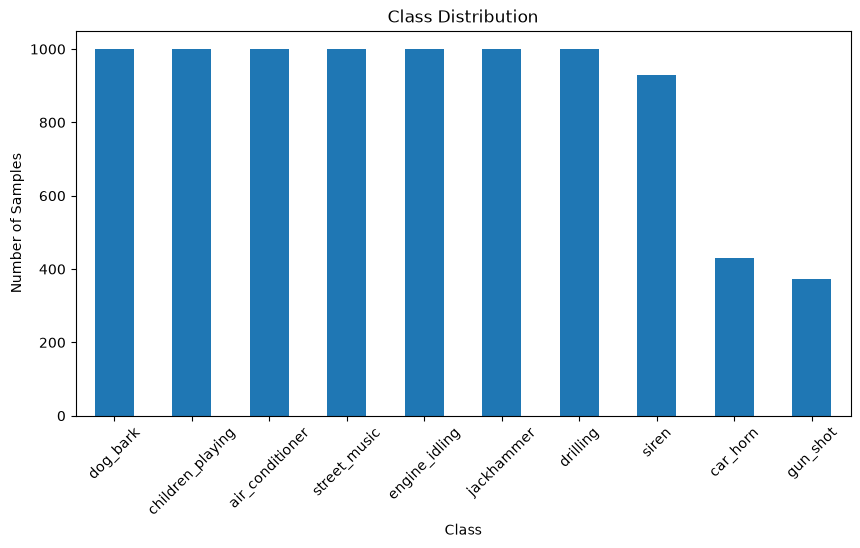

In [5]:
plt.figure(figsize=(10,5))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.show()

In [6]:
sample_rates = []

for i in range(20):

    row = metadata.iloc[i]

    path = os.path.join(
        dataset_path,
        "audio",
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

    y, sr = librosa.load(path, sr=None)

    sample_rates.append(sr)

print(set(sample_rates))

/opt/anaconda3/envs/dtln/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{44100}


In [7]:
total_duration = 0

for _, row in metadata.iterrows():

    path = os.path.join(
        dataset_path,
        "audio",
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

    y, sr = librosa.load(path, sr=None)

    total_duration += len(y)/sr

print("Total Duration (minutes):", total_duration/60)

Total Duration (minutes): 525.0146768829833


In [8]:
samples = metadata.groupby("class").first()

samples

,slice_file_name,fsID,start,end,salience,fold,classID
class,,,,,,,
air_conditioner,100852-0-0-0.wav,100852,0.000000,4.000000,1,5,0
car_horn,100648-1-0-0.wav,100648,4.823402,5.471927,2,10,1
children_playing,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2
dog_bark,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3
drilling,103199-4-0-0.wav,103199,0.000000,4.000000,1,3,4
engine_idling,102857-5-0-0.wav,102857,0.000000,4.000000,1,10,5
gun_shot,102305-6-0-0.wav,102305,0.000000,2.611610,1,1,6
jackhammer,103074-7-0-0.wav,103074,3.341279,7.341279,1,1,7
siren,102853-8-0-0.wav,102853,0.000000,4.000000,2,7,8


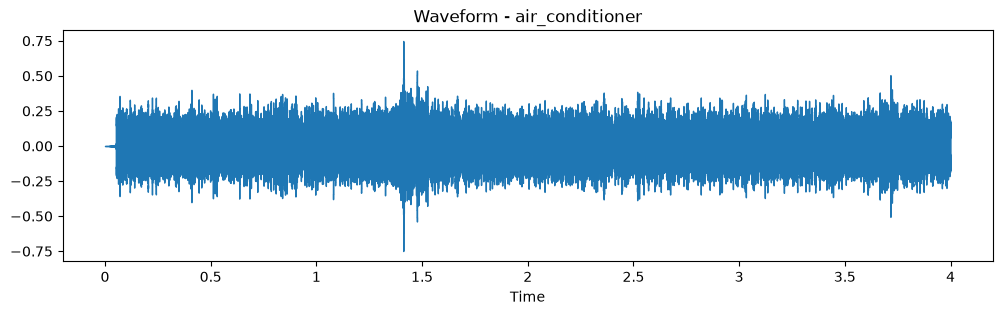

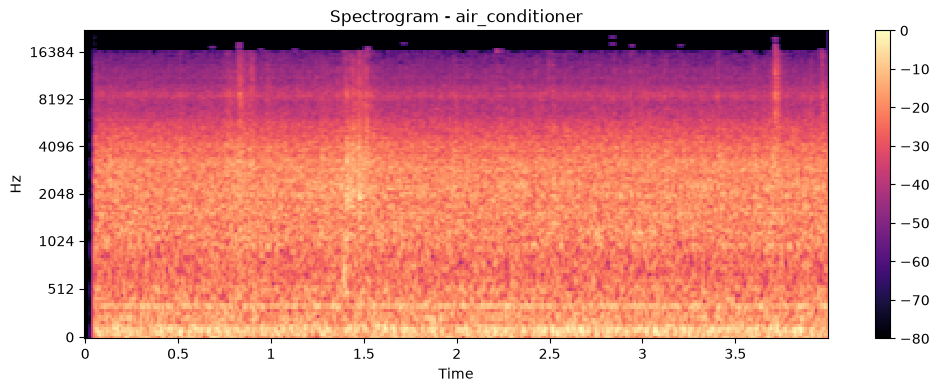

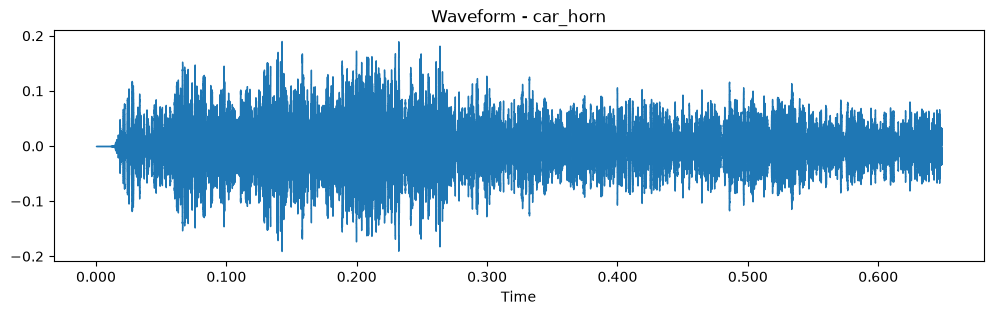

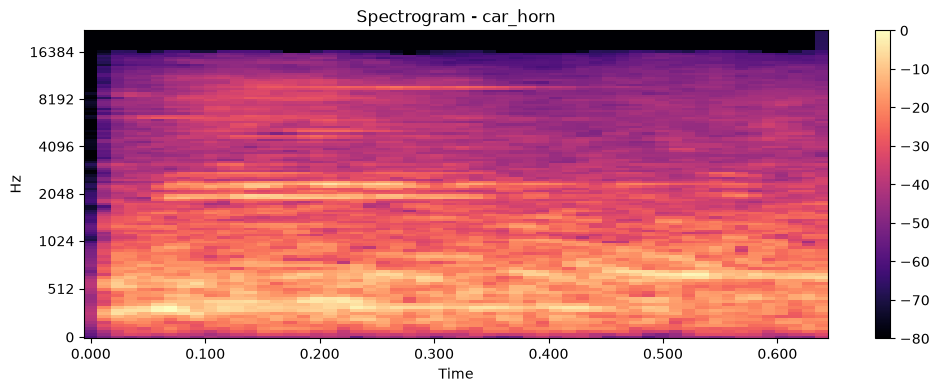

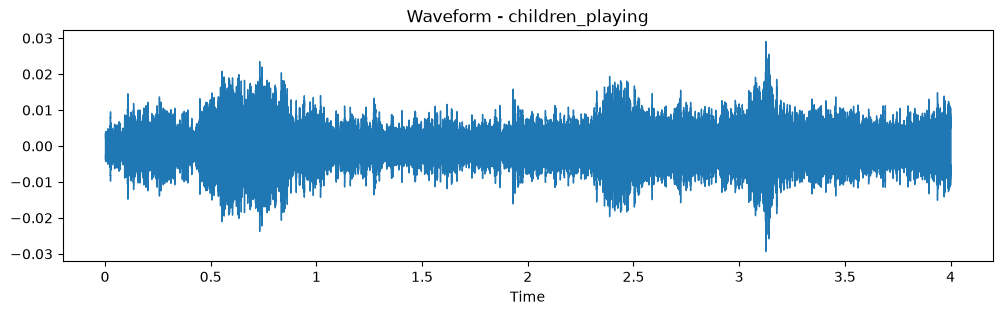

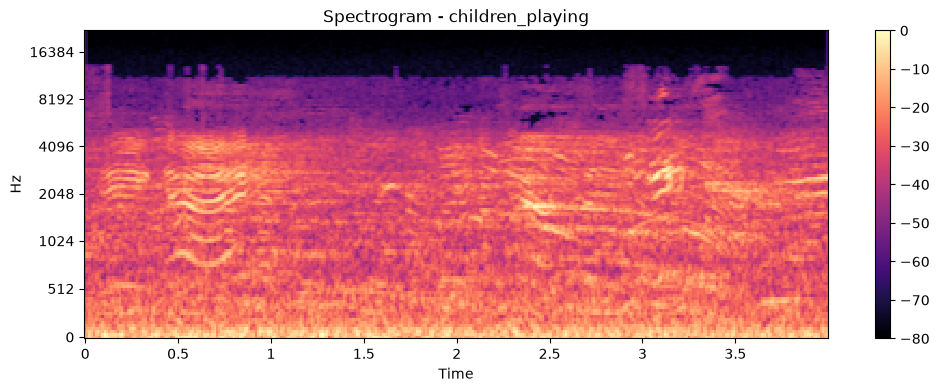

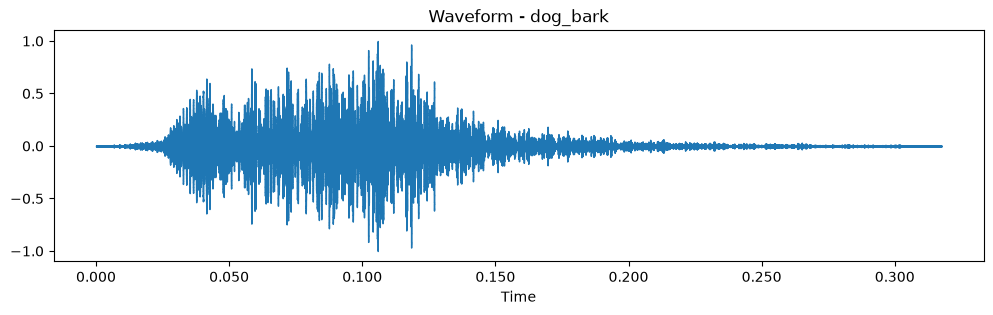

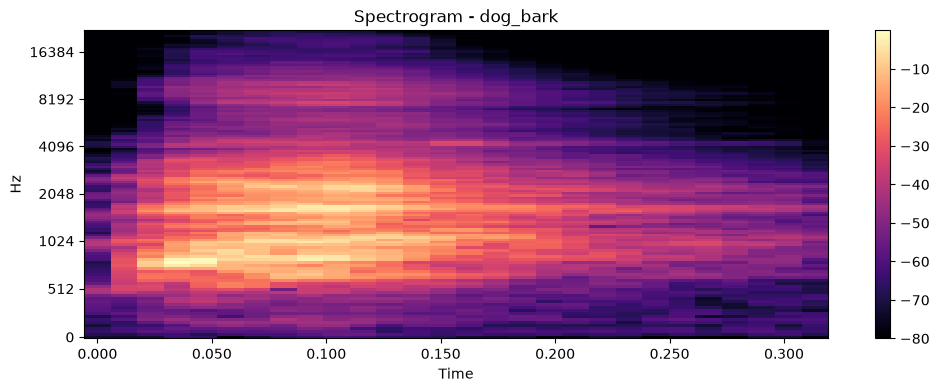

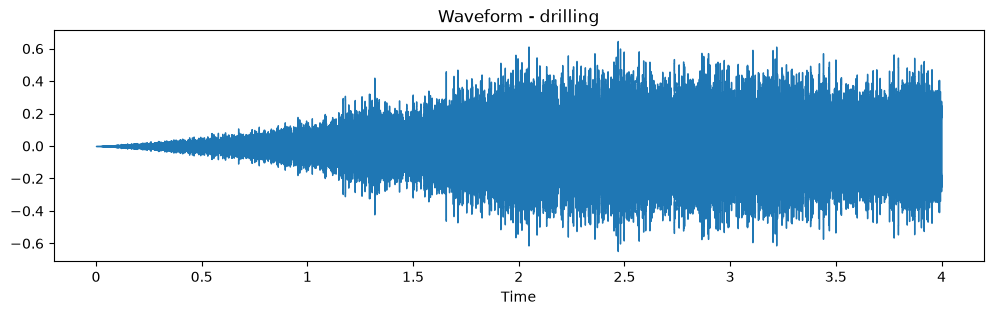

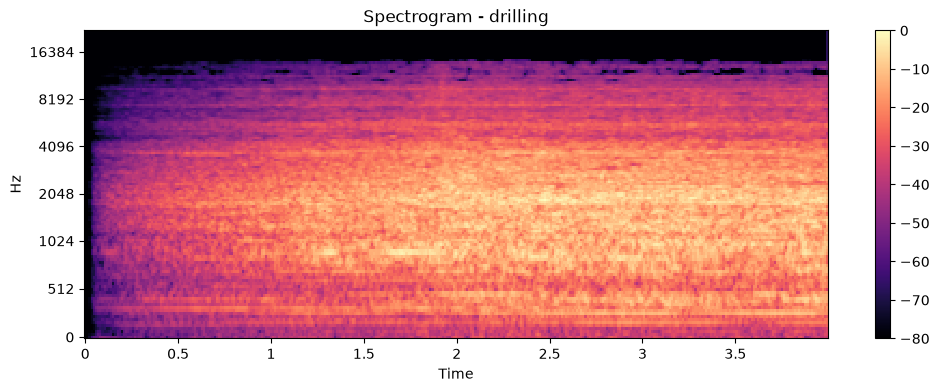

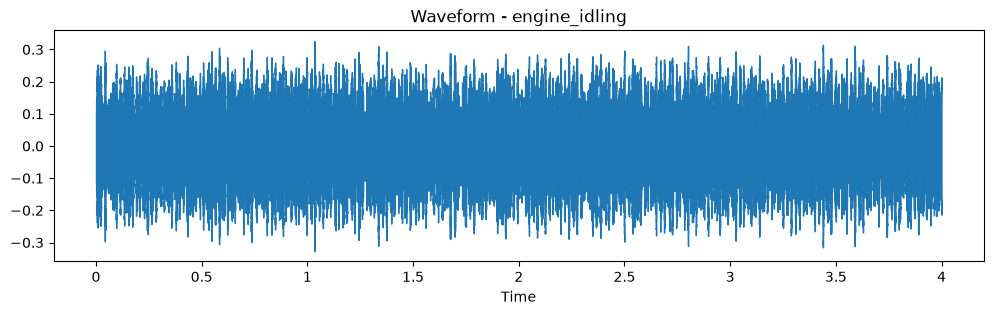

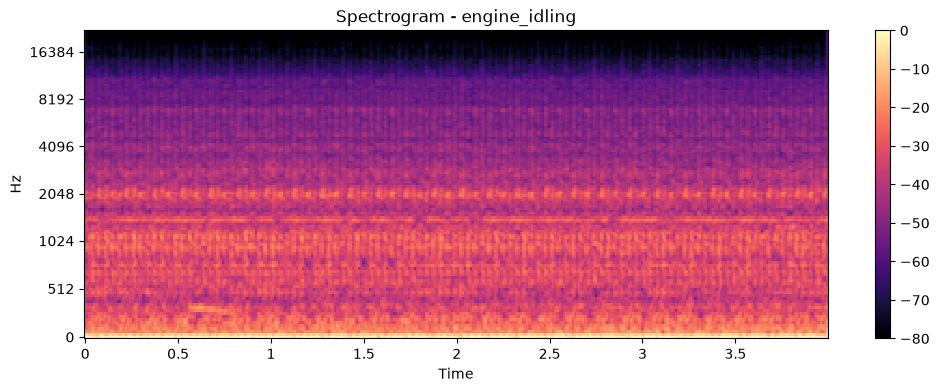

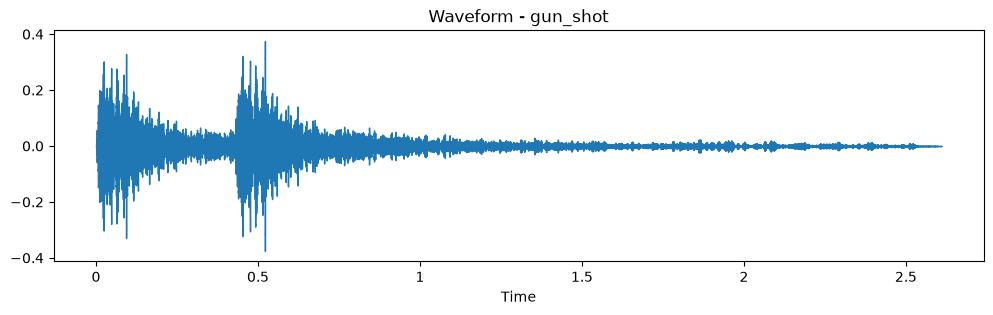

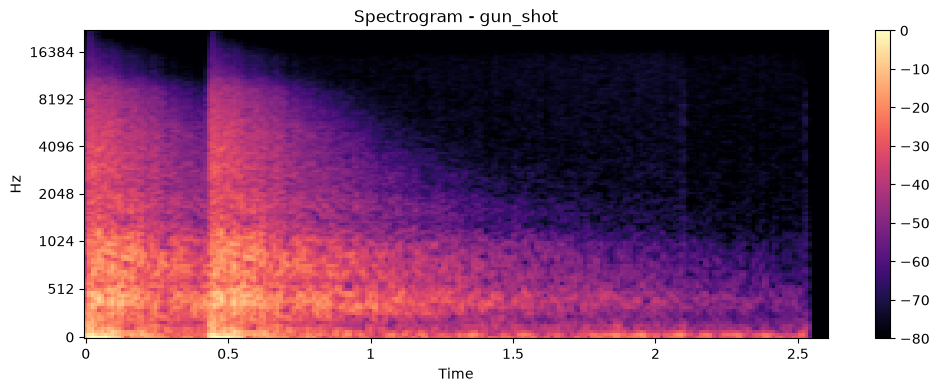

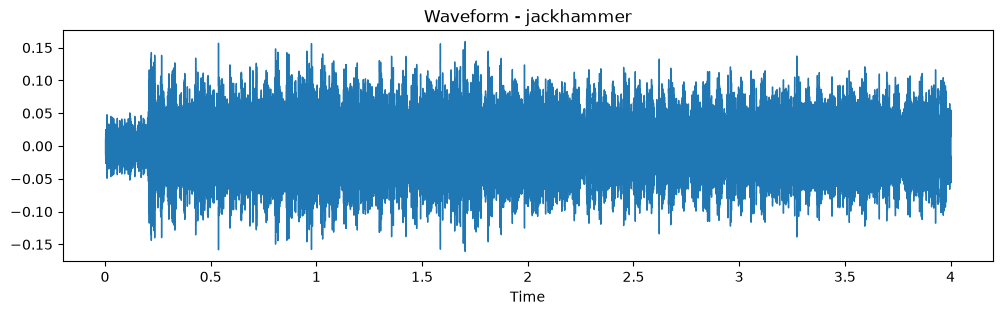

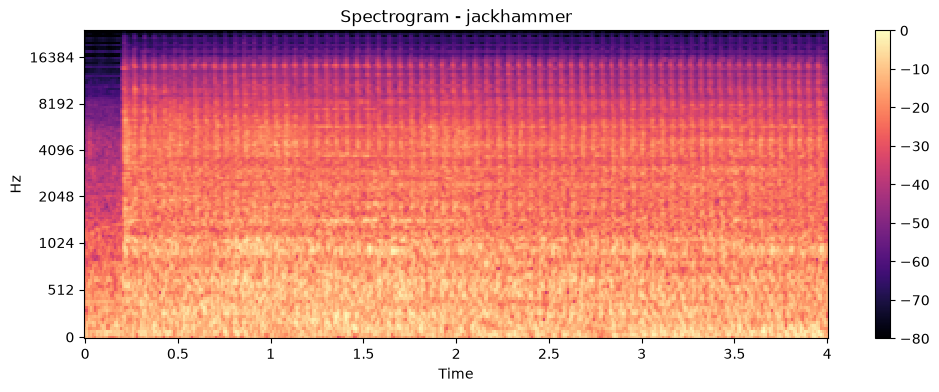

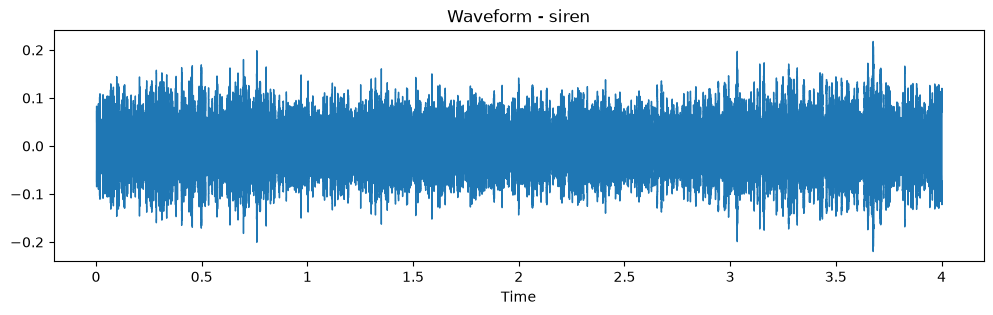

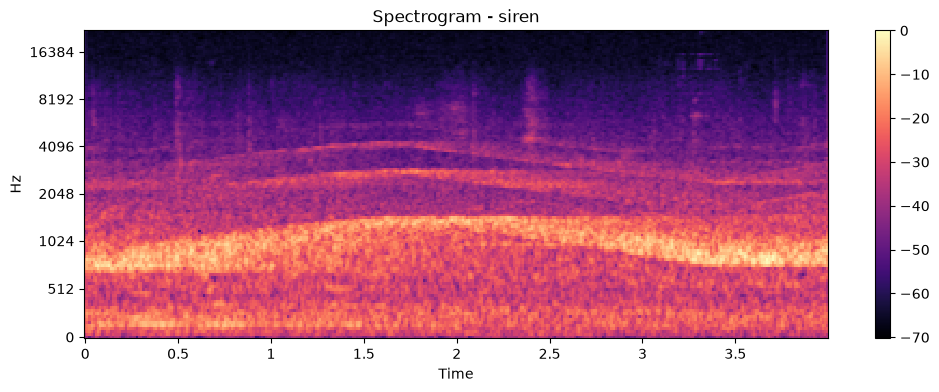

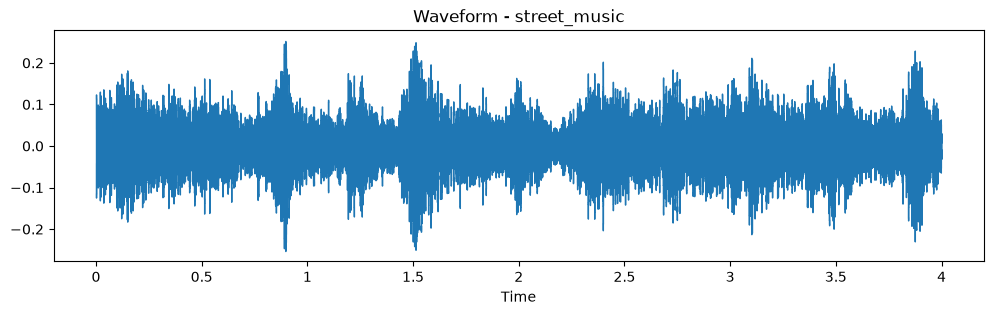

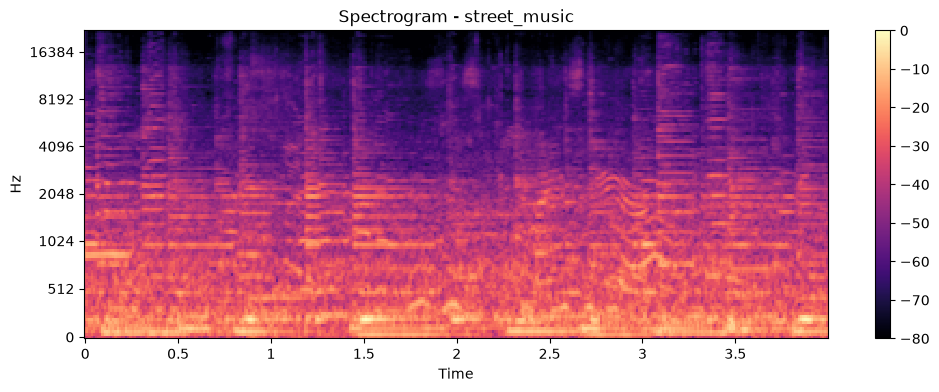

In [9]:
for cls, row in samples.iterrows():

    path = os.path.join(
        dataset_path,
        "audio",
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

    y, sr = librosa.load(path, sr=None)

    plt.figure(figsize=(12,3))

    librosa.display.waveshow(y, sr=sr)

    plt.title(f"Waveform - {cls}")

    plt.show()


    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    plt.figure(figsize=(12,4))

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar()

    plt.title(f"Spectrogram - {cls}")

    plt.show()

In [10]:
summary = pd.DataFrame({
    "Metric":[
        "Total Samples",
        "Number of Classes",
        "Sample Rate",
        "Total Duration (minutes)"
    ],
    "Value":[
        len(metadata),
        metadata["class"].nunique(),
        list(set(sample_rates)),
        round(total_duration/60,2)
    ]
})

summary

,Metric,Value
0,Total Samples,8732
1,Number of Classes,10
2,Sample Rate,[44100]
3,Total Duration (minutes),525.01


# Audio Preprocessing

In [11]:
class AudioPreprocessor:

    def __init__(self, sr=16000, n_mels=64,
                 n_fft=1024, hop_length=512,
                 target_duration=4.0):

        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_samples = int(sr * target_duration)

    def load_and_resample(self, path):

        y, original_sr = librosa.load(
            path,
            sr=None,
            mono=True
        )

        if original_sr != self.sr:
            y = librosa.resample(
                y,
                orig_sr=original_sr,
                target_sr=self.sr
            )

        return y, original_sr

    def pad_or_truncate(self, y):

        if len(y) < self.target_samples:

            padding = self.target_samples - len(y)

            y = np.pad(
                y,
                (0, padding)
            )

        else:

            y = y[:self.target_samples]

        return y

    def extract_mel_spectrogram(self, y):

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        mel_db = np.expand_dims(
            mel_db,
            axis=0
        )

        return mel_db

    def process(self, path):

        y, original_sr = self.load_and_resample(path)

        y = self.pad_or_truncate(y)

        mel = self.extract_mel_spectrogram(y)

        return mel

In [12]:
preprocessor = AudioPreprocessor()

In [13]:
sample = metadata.iloc[0]

audio_path = os.path.join(
    dataset_path,
    "audio",
    f"fold{sample['fold']}",
    sample["slice_file_name"]
)

mel = preprocessor.process(audio_path)

print(mel.shape)

(1, 64, 126)


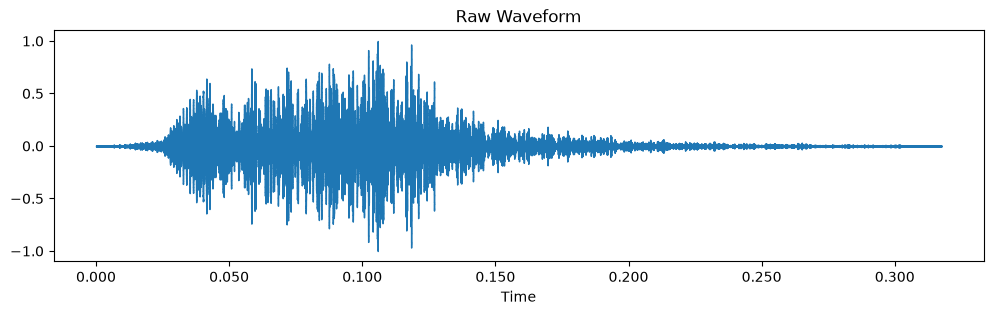

In [14]:
y_raw, sr_raw = librosa.load(audio_path, sr=None)

plt.figure(figsize=(12,3))

librosa.display.waveshow(y_raw, sr=sr_raw)

plt.title("Raw Waveform")

plt.show()

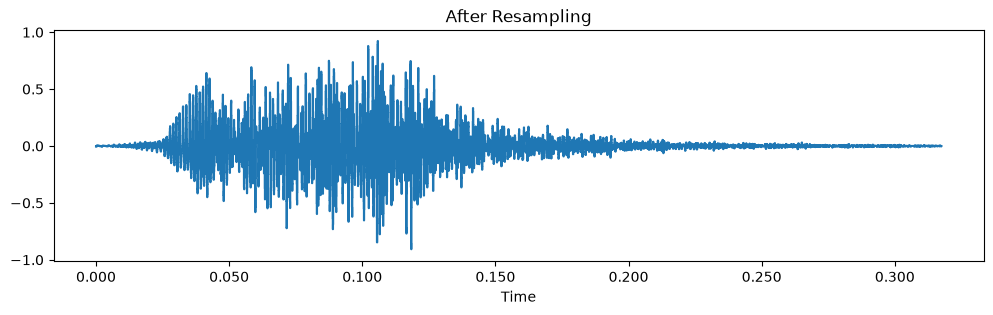

In [15]:
y_resampled, _ = preprocessor.load_and_resample(audio_path)

plt.figure(figsize=(12,3))

librosa.display.waveshow(
    y_resampled,
    sr=preprocessor.sr
)

plt.title("After Resampling")

plt.show()

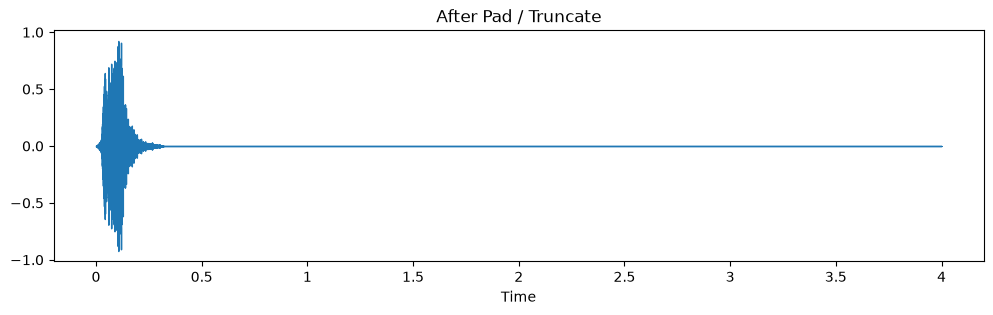

In [16]:
y_fixed = preprocessor.pad_or_truncate(
    y_resampled
)

plt.figure(figsize=(12,3))

librosa.display.waveshow(
    y_fixed,
    sr=preprocessor.sr
)

plt.title("After Pad / Truncate")

plt.show()

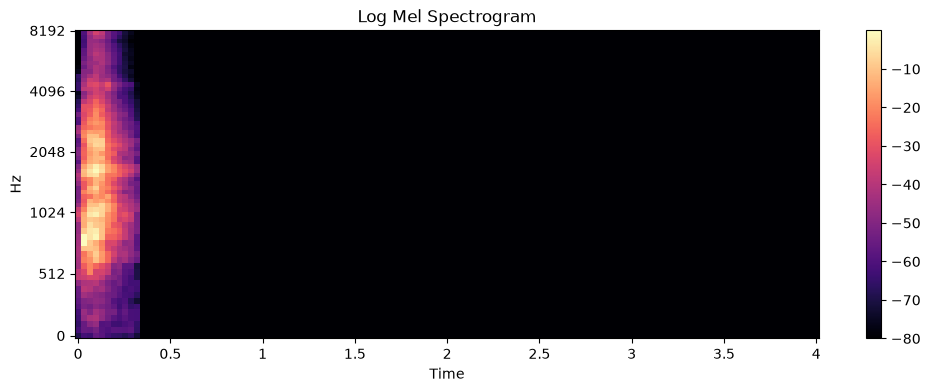

In [17]:
mel = preprocessor.extract_mel_spectrogram(
    y_fixed
)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    mel[0],
    sr=preprocessor.sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Log Mel Spectrogram")

plt.show()

In [18]:
encoder = LabelEncoder()

metadata["label"] = encoder.fit_transform(metadata["class"])

metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class,label
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,3
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,2
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,2
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,2
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,2


In [19]:
file_list = []

for _, row in metadata.iterrows():

    path = os.path.join(
        dataset_path,
        "audio",
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

    file_list.append(path)

labels = metadata["label"].tolist()

print("Total Files :", len(file_list))

Total Files : 8732


# Dataset and Dataloader

In [20]:
train_files, temp_files, train_labels, temp_labels = train_test_split(

    file_list,
    labels,

    test_size=0.30,

    random_state=42,

    stratify=labels
)

In [21]:
val_files, test_files, val_labels, test_labels = train_test_split(

    temp_files,
    temp_labels,

    test_size=0.50,

    random_state=42,

    stratify=temp_labels
)

In [22]:
print("Train :", len(train_files))
print("Validation :", len(val_files))
print("Test :", len(test_files))

Train : 6112
Validation : 1310
Test : 1310


In [23]:
class AudioDataset(Dataset):

    def __init__(
        self,
        file_list,
        labels,
        preprocessor,
        augment=None
    ):

        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment

    def __len__(self):

        return len(self.file_list)

    def __getitem__(self, idx):

        spec = self.preprocessor.process(
            self.file_list[idx]
        )

        spec = torch.tensor(
            spec,
            dtype=torch.float32
        )

        if self.augment:

            spec = self.augment(spec)

        label = torch.tensor(
            self.labels[idx]
        )

        return spec, label

In [24]:
train_dataset = AudioDataset(

    train_files,
    train_labels,

    preprocessor
)

val_dataset = AudioDataset(

    val_files,
    val_labels,

    preprocessor
)

test_dataset = AudioDataset(

    test_files,
    test_labels,

    preprocessor
)

In [25]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

In [26]:
spec, label = train_dataset[0]

print(spec.shape)

print(label)

torch.Size([1, 64, 126])
tensor(7)


# CNN Model Architecture

In [27]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super(AudioCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 15, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [28]:
num_classes = len(encoder.classes_)

model = AudioCNN(num_classes)

print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7680, out_features=256, bias=True)
 

In [29]:
sample, label = train_dataset[0]

sample = sample.unsqueeze(0)  # Add batch dimension

output = model(sample)

print(output.shape)

torch.Size([1, 10])


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [31]:
model = model.to(device)

# Training without Augmentation

In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [33]:
num_epochs = 20

train_losses = []

train_accuracies = []

val_accuracies = []

In [34]:
for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for spectrograms, labels in train_loader:

        spectrograms = spectrograms.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(spectrograms)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for spectrograms, labels in val_loader:

            spectrograms = spectrograms.to(device)

            labels = labels.to(device)

            outputs = model(spectrograms)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch 1/20 | Loss: 1.6700 | Train Acc: 42.13% | Val Acc: 61.53%
Epoch 2/20 | Loss: 1.1866 | Train Acc: 57.48% | Val Acc: 67.48%
Epoch 3/20 | Loss: 0.9671 | Train Acc: 65.85% | Val Acc: 68.09%
Epoch 4/20 | Loss: 0.8174 | Train Acc: 72.37% | Val Acc: 80.69%
Epoch 5/20 | Loss: 0.7168 | Train Acc: 76.33% | Val Acc: 75.57%
Epoch 6/20 | Loss: 0.5949 | Train Acc: 79.32% | Val Acc: 82.37%
Epoch 7/20 | Loss: 0.5409 | Train Acc: 82.15% | Val Acc: 79.24%
Epoch 8/20 | Loss: 0.4755 | Train Acc: 83.16% | Val Acc: 71.76%
Epoch 9/20 | Loss: 0.4035 | Train Acc: 86.08% | Val Acc: 82.75%
Epoch 10/20 | Loss: 0.3725 | Train Acc: 86.99% | Val Acc: 88.09%
Epoch 11/20 | Loss: 0.3408 | Train Acc: 88.43% | Val Acc: 89.85%
Epoch 12/20 | Loss: 0.3121 | Train Acc: 89.45% | Val Acc: 76.56%
Epoch 13/20 | Loss: 0.2708 | Train Acc: 90.85% | Val Acc: 84.81%
Epoch 14/20 | Loss: 0.2399 | Train Acc: 91.69% | Val Acc: 88.02%
Epoch 15/20 | Loss: 0.2363 | Train Acc: 91.67% | Val Acc: 89.39%
Epoch 16/20 | Loss: 0.2082 | Train

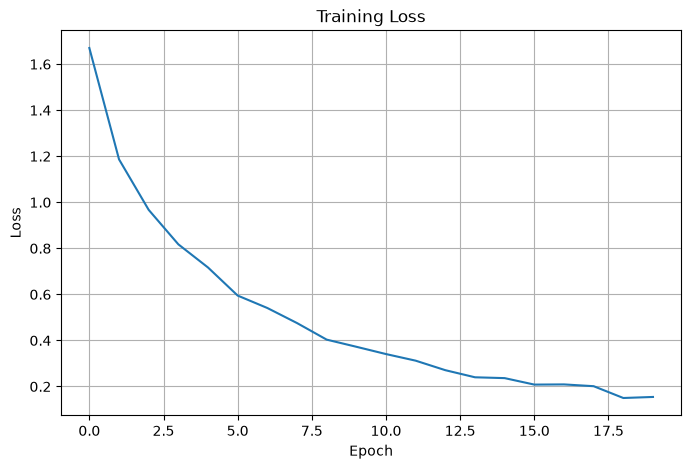

In [35]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

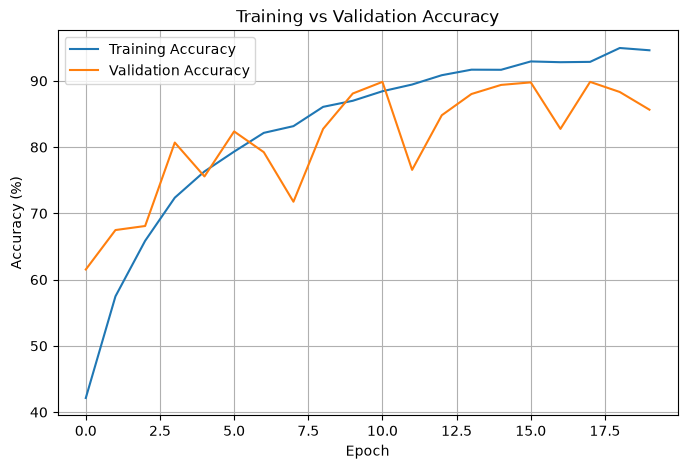

In [36]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")

plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

# Step-6 Evaluation without augmentation

In [ ]:

from sklearn.metrics import accuracy_score

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for spectrograms, labels in test_loader:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)

        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(true_labels, predictions)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")

Test Accuracy : 86.49%


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=encoder.classes_
    )
)

                  precision    recall  f1-score   support

 air_conditioner       0.93      0.86      0.89       150
        car_horn       0.97      0.89      0.93        65
children_playing       0.74      0.81      0.78       150
        dog_bark       0.69      0.96      0.80       150
        drilling       0.86      0.91      0.89       150
   engine_idling       0.90      0.89      0.90       150
        gun_shot       1.00      0.93      0.96        56
      jackhammer       0.94      0.87      0.90       150
           siren       0.93      0.92      0.92       139
    street_music       0.97      0.67      0.79       150

        accuracy                           0.86      1310
       macro avg       0.89      0.87      0.88      1310
    weighted avg       0.88      0.86      0.87      1310



  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


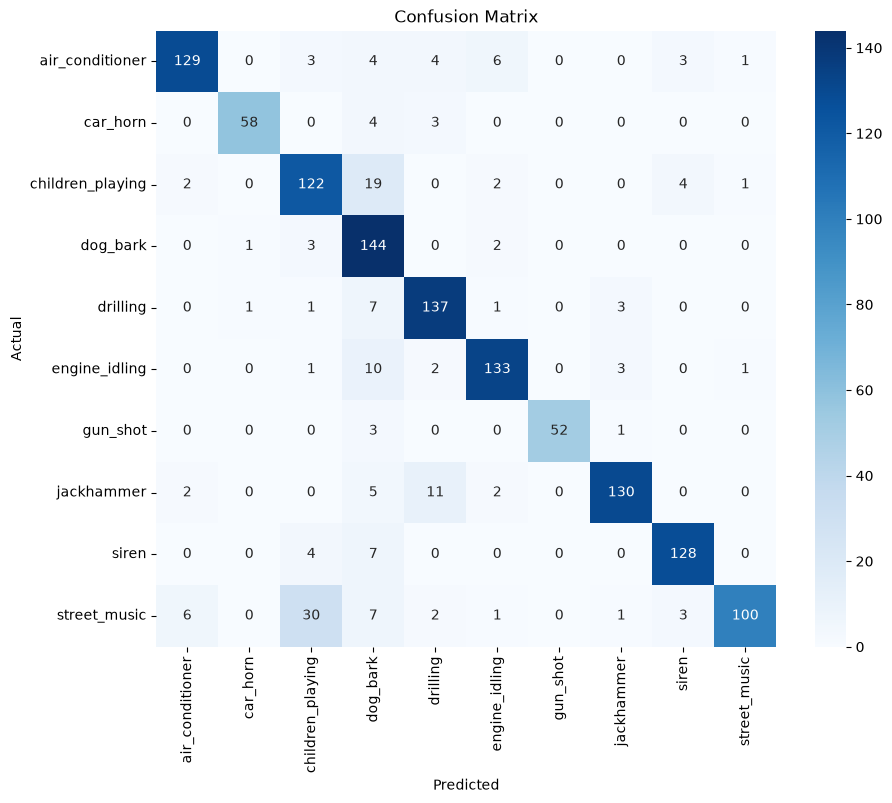

In [ ]:
!pip install seaborn
from sklearn.metrics import confusion_matrix

import seaborn as sns
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
correct = []

model.eval()

with torch.no_grad():

    for spectrograms, labels in test_loader:

        outputs = model(spectrograms.to(device))

        _, predicted = torch.max(outputs,1)

        for i in range(len(labels)):

            if predicted[i].cpu()==labels[i]:

                correct.append(
                    (
                        spectrograms[i],
                        labels[i],
                        predicted[i].cpu()
                    )
                )

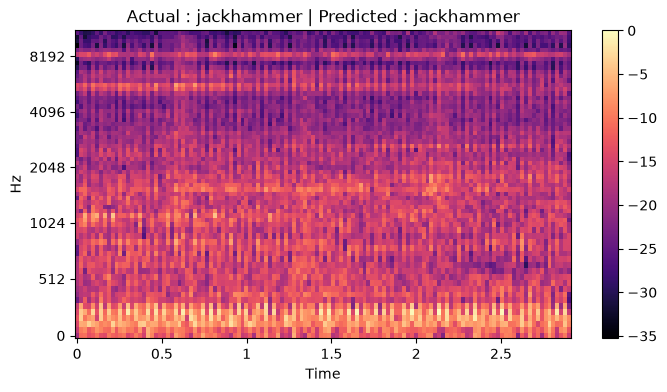

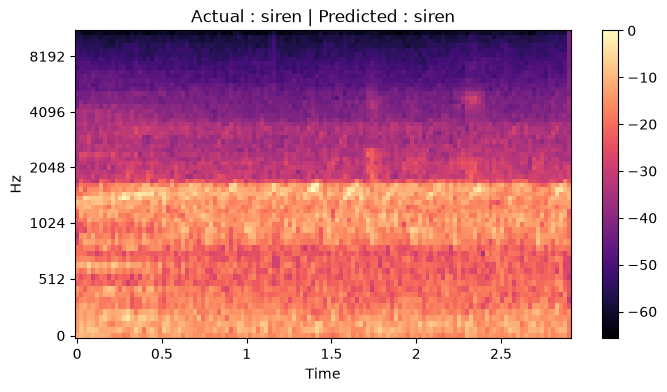

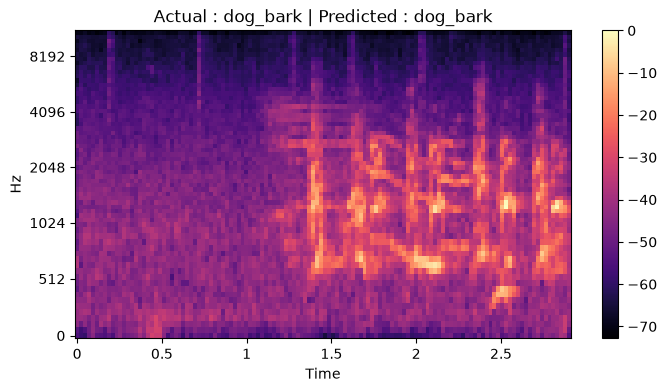

In [ ]:
for i in range(3):

    spec,label,pred = correct[i]

    plt.figure(figsize=(8,4))

    librosa.display.specshow(
        spec.squeeze().numpy(),
        x_axis="time",
        y_axis="mel"
    )

    plt.title(
        f"Actual : {encoder.inverse_transform([label])[0]} | "
        f"Predicted : {encoder.inverse_transform([pred])[0]}"
    )

    plt.colorbar()

    plt.show()

In [ ]:
incorrect=[]

model.eval()

with torch.no_grad():

    for spectrograms, labels in test_loader:

        outputs=model(spectrograms.to(device))

        _,predicted=torch.max(outputs,1)

        for i in range(len(labels)):

            if predicted[i].cpu()!=labels[i]:

                incorrect.append(

                    (
                        spectrograms[i],
                        labels[i],
                        predicted[i].cpu()
                    )
                )

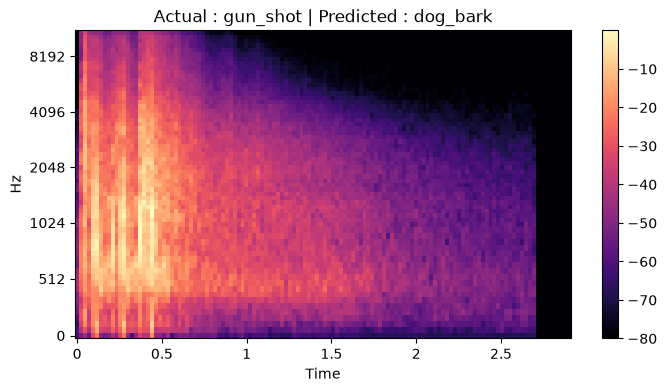

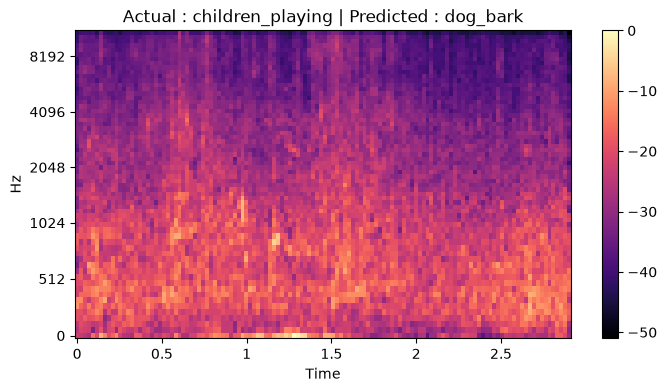

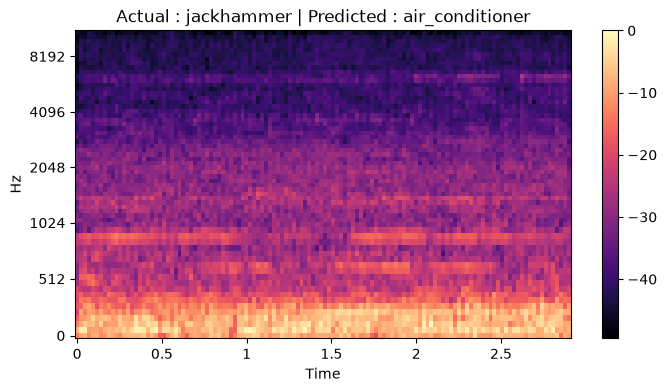

In [ ]:
for i in range(3):

    spec,label,pred=incorrect[i]

    plt.figure(figsize=(8,4))

    librosa.display.specshow(
        spec.squeeze().numpy(),
        x_axis="time",
        y_axis="mel"
    )

    plt.title(
        f"Actual : {encoder.inverse_transform([label])[0]} | "
        f"Predicted : {encoder.inverse_transform([pred])[0]}"
    )

    plt.colorbar()

    plt.show()

# PART-B

In [ ]:

import random

class SpecAugment:

    def __init__(
        self,
        freq_mask_param=15,
        time_mask_param=35,
        num_freq_masks=2,
        num_time_masks=2
    ):

        self.F = freq_mask_param
        self.T = time_mask_param

        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def freq_mask(self, spec):

        _, n_mels, n_frames = spec.shape

        f = random.randint(0, self.F)

        if f == 0:
            return spec

        f0 = random.randint(0, n_mels - f)

        spec[:, f0:f0+f, :] = 0

        return spec

    def time_mask(self, spec):

        _, n_mels, n_frames = spec.shape

        t = random.randint(0, self.T)

        if t == 0:
            return spec

        t0 = random.randint(0, n_frames - t)

        spec[:, :, t0:t0+t] = 0

        return spec

    def __call__(self, spec):

        spec = spec.clone()

        for _ in range(self.num_freq_masks):
            spec = self.freq_mask(spec)

        for _ in range(self.num_time_masks):
            spec = self.time_mask(spec)

        return spec

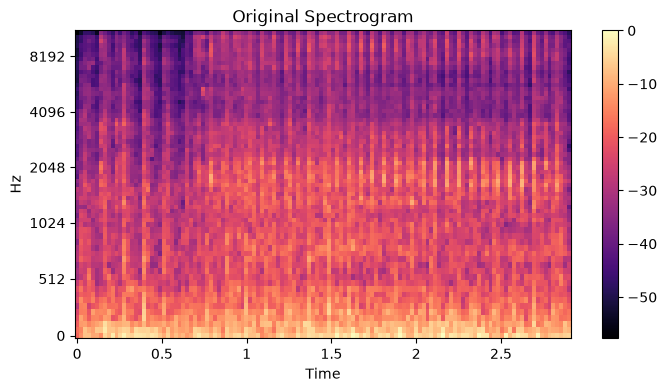

In [ ]:
augment = SpecAugment()
sample_spec, _ = train_dataset[0]

plt.figure(figsize=(8,4))

librosa.display.specshow(
    sample_spec.squeeze().numpy(),
    x_axis="time",
    y_axis="mel"
)

plt.title("Original Spectrogram")

plt.colorbar()

plt.show()

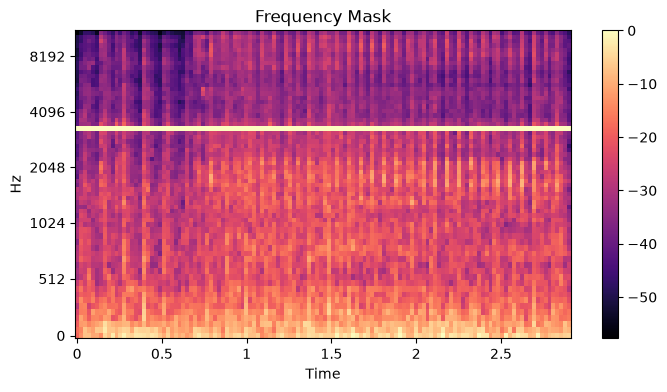

In [ ]:
freq_aug = SpecAugment(
    num_freq_masks=1,
    num_time_masks=0
)

masked = freq_aug(sample_spec)

plt.figure(figsize=(8,4))

librosa.display.specshow(
    masked.squeeze().numpy(),
    x_axis="time",
    y_axis="mel"
)

plt.title("Frequency Mask")

plt.colorbar()

plt.show()

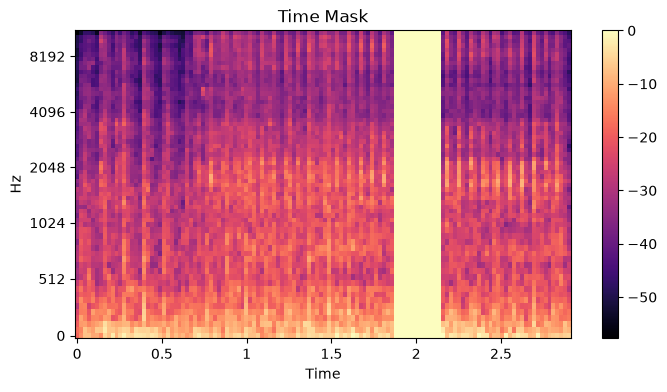

In [ ]:
time_aug = SpecAugment(
    num_freq_masks=0,
    num_time_masks=1
)

masked = time_aug(sample_spec)

plt.figure(figsize=(8,4))

librosa.display.specshow(
    masked.squeeze().numpy(),
    x_axis="time",
    y_axis="mel"
)

plt.title("Time Mask")

plt.colorbar()

plt.show()

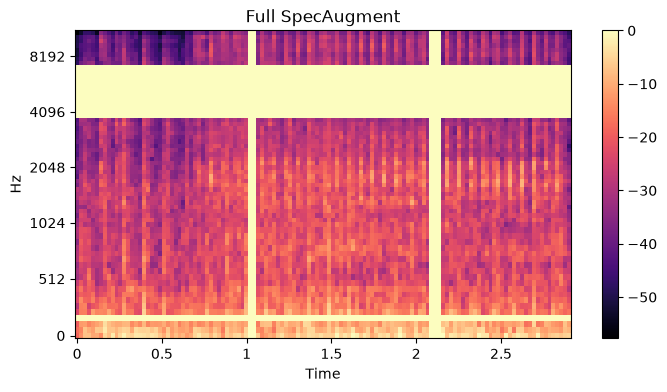

In [ ]:
full_aug = SpecAugment()

masked = full_aug(sample_spec)

plt.figure(figsize=(8,4))

librosa.display.specshow(
    masked.squeeze().numpy(),
    x_axis="time",
    y_axis="mel"
)

plt.title("Full SpecAugment")

plt.colorbar()

plt.show()

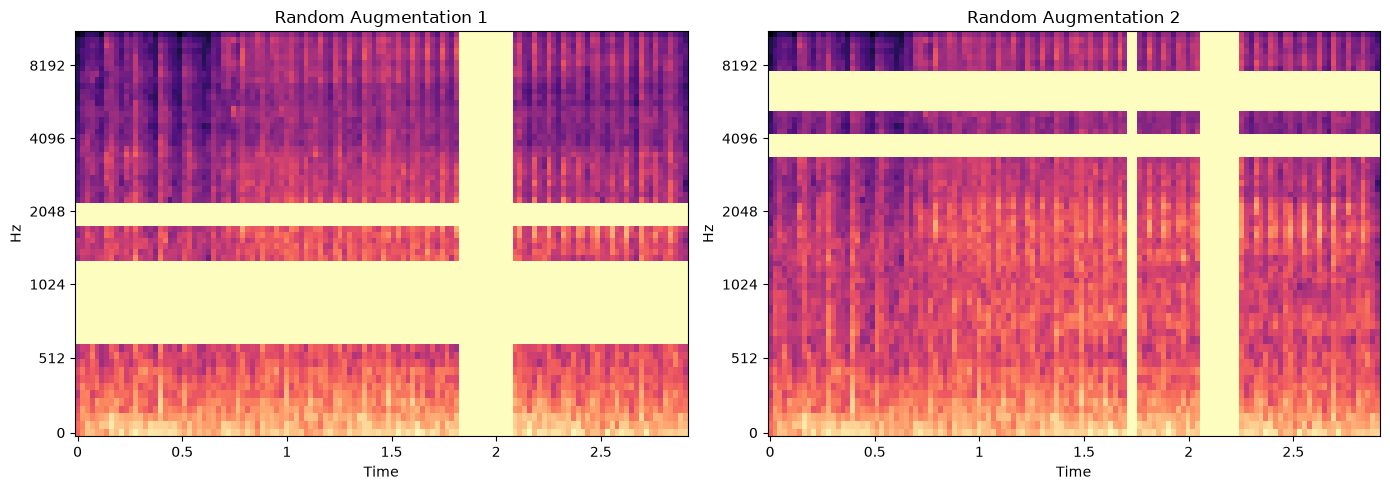

In [ ]:
plt.figure(figsize=(14,5))

for i in range(2):

    plt.subplot(1,2,i+1)

    aug_spec = full_aug(sample_spec)

    librosa.display.specshow(
        aug_spec.squeeze().numpy(),
        x_axis="time",
        y_axis="mel"
    )

    plt.title(f"Random Augmentation {i+1}")

plt.tight_layout()

plt.show()

# Training with SpecAugment

In [ ]:
train_dataset_aug = AudioDataset(
    train_files,
    train_labels,
    preprocessor,
    augment=SpecAugment()
)

In [ ]:
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=32,
    shuffle=True
)

In [ ]:
model_aug = AudioCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

In [ ]:
train_losses_aug = []
train_accuracies_aug = []
val_accuracies_aug = []

num_epochs = 20

for epoch in range(num_epochs):

    model_aug.train()

    running_loss = 0
    correct = 0
    total = 0

    for spectrograms, labels in train_loader_aug:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_aug(spectrograms)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader_aug)
    train_acc = 100 * correct / total

    train_losses_aug.append(train_loss)
    train_accuracies_aug.append(train_acc)

    # Validation
    model_aug.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for spectrograms, labels in val_loader:

            spectrograms = spectrograms.to(device)
            labels = labels.to(device)

            outputs = model_aug(spectrograms)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies_aug.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.2f}% | "
        f"Val Acc {val_acc:.2f}%"
    )

Epoch 1/20 | Loss 2.1066 | Train Acc 23.25% | Val Acc 31.45%
Epoch 2/20 | Loss 1.8754 | Train Acc 26.64% | Val Acc 32.21%
Epoch 3/20 | Loss 1.7879 | Train Acc 29.99% | Val Acc 32.37%
Epoch 4/20 | Loss 1.7107 | Train Acc 32.84% | Val Acc 35.80%
Epoch 5/20 | Loss 1.6395 | Train Acc 35.90% | Val Acc 40.92%
Epoch 6/20 | Loss 1.5895 | Train Acc 37.55% | Val Acc 43.66%
Epoch 7/20 | Loss 1.5505 | Train Acc 40.17% | Val Acc 56.18%
Epoch 8/20 | Loss 1.4921 | Train Acc 42.41% | Val Acc 53.36%
Epoch 9/20 | Loss 1.4627 | Train Acc 43.83% | Val Acc 46.49%
Epoch 10/20 | Loss 1.4341 | Train Acc 45.01% | Val Acc 58.93%
Epoch 11/20 | Loss 1.3778 | Train Acc 47.27% | Val Acc 57.02%
Epoch 12/20 | Loss 1.3527 | Train Acc 48.81% | Val Acc 54.73%
Epoch 13/20 | Loss 1.3478 | Train Acc 49.39% | Val Acc 61.53%
Epoch 14/20 | Loss 1.2877 | Train Acc 50.77% | Val Acc 65.88%
Epoch 15/20 | Loss 1.2526 | Train Acc 53.50% | Val Acc 63.59%
Epoch 16/20 | Loss 1.2496 | Train Acc 53.24% | Val Acc 60.53%
Epoch 17/20 | Los

# Evaluation With SpecAugment 

In [ ]:
from sklearn.metrics import accuracy_score

model_aug.eval()

predictions_aug = []
true_labels_aug = []

with torch.no_grad():

    for spectrograms, labels in test_loader:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model_aug(spectrograms)

        _, predicted = torch.max(outputs, 1)

        predictions_aug.extend(predicted.cpu().numpy())
        true_labels_aug.extend(labels.cpu().numpy())

test_accuracy_aug = accuracy_score(
    true_labels_aug,
    predictions_aug
)

print(f"Test Accuracy : {test_accuracy_aug*100:.2f}%")

Test Accuracy : 65.73%


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels_aug,
        predictions_aug,
        target_names=encoder.classes_
    )
)

                  precision    recall  f1-score   support

 air_conditioner       0.53      0.27      0.36       150
        car_horn       0.88      0.78      0.83        65
children_playing       0.40      0.83      0.54       150
        dog_bark       0.95      0.65      0.77       150
        drilling       0.85      0.80      0.82       150
   engine_idling       0.89      0.26      0.40       150
        gun_shot       0.93      0.95      0.94        56
      jackhammer       0.74      0.71      0.72       150
           siren       0.94      0.71      0.81       139
    street_music       0.48      0.87      0.62       150

        accuracy                           0.66      1310
       macro avg       0.76      0.68      0.68      1310
    weighted avg       0.74      0.66      0.65      1310



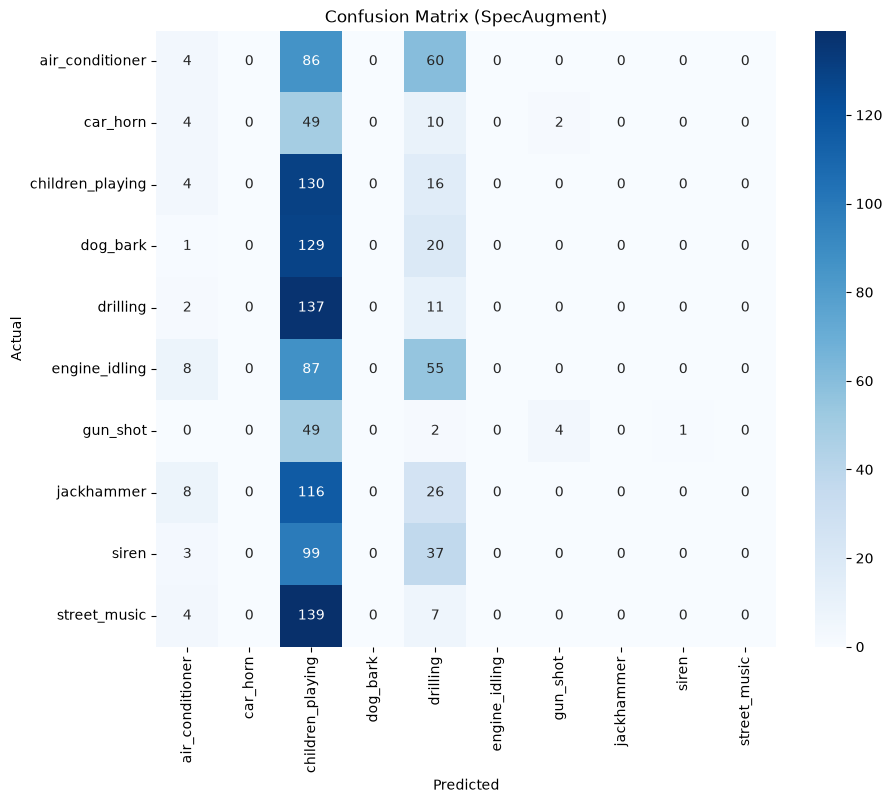

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    true_labels_aug,
    predictions_aug
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SpecAugment)")
plt.show()

In [ ]:
correct = []

model_aug.eval()

with torch.no_grad():

    for spectrograms, labels in test_loader:

        outputs = model_aug(spectrograms.to(device))

        _, predicted = torch.max(outputs,1)

        for i in range(len(labels)):

            if predicted[i].cpu() == labels[i]:

                correct.append(
                    (
                        spectrograms[i],
                        labels[i],
                        predicted[i].cpu()
                    )
                )

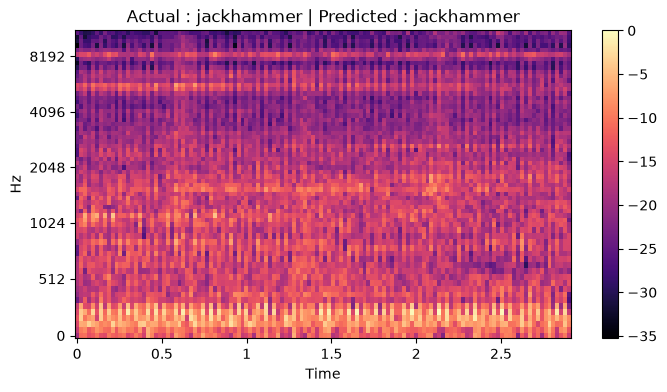

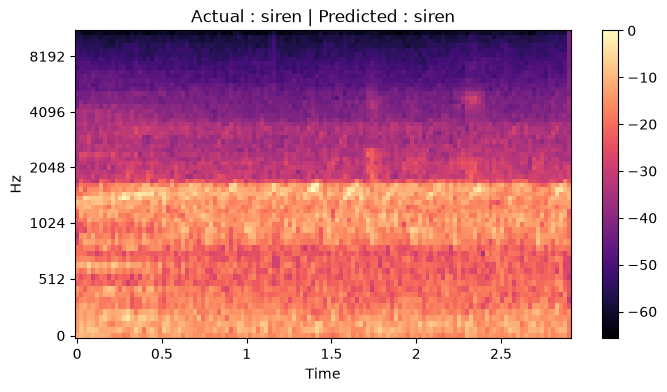

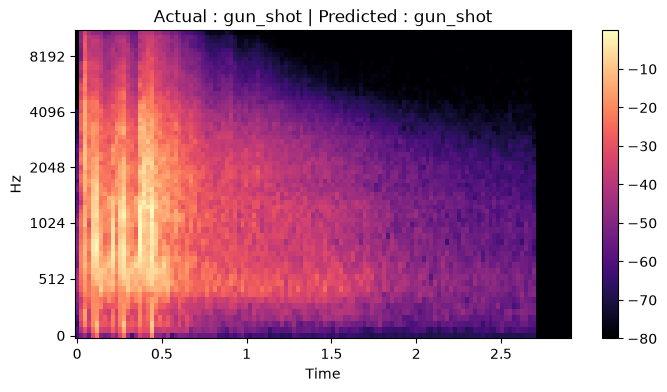

In [ ]:
for i in range(3):

    spec,label,pred = correct[i]

    plt.figure(figsize=(8,4))

    librosa.display.specshow(
        spec.squeeze().numpy(),
        x_axis="time",
        y_axis="mel"
    )

    plt.title(
        f"Actual : {encoder.inverse_transform([label])[0]} | "
        f"Predicted : {encoder.inverse_transform([pred])[0]}"
    )

    plt.colorbar()

    plt.show()

In [ ]:
incorrect=[]

model_aug.eval()

with torch.no_grad():

    for spectrograms, labels in test_loader:

        outputs=model_aug(spectrograms.to(device))

        _,predicted=torch.max(outputs,1)

        for i in range(len(labels)):

            if predicted[i].cpu()!=labels[i]:

                incorrect.append(
                    (
                        spectrograms[i],
                        labels[i],
                        predicted[i].cpu()
                    )
                )

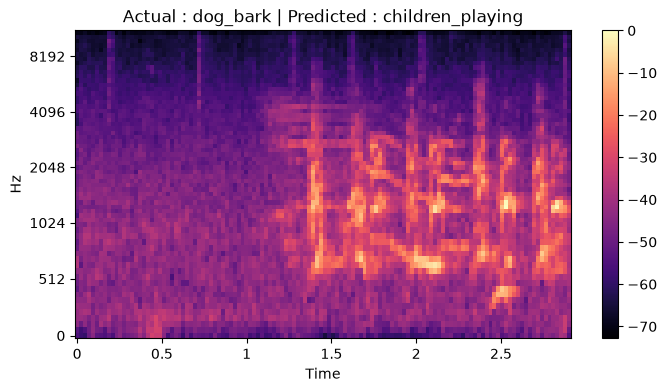

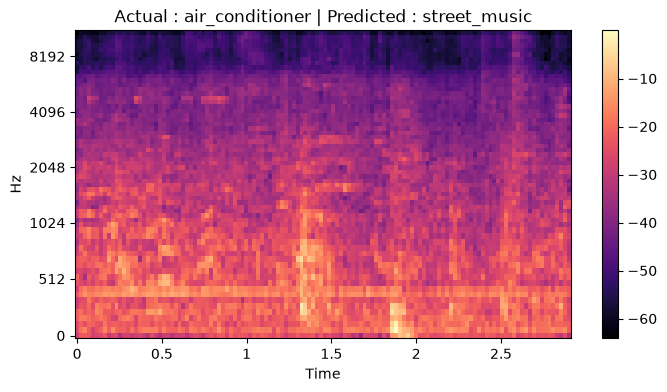

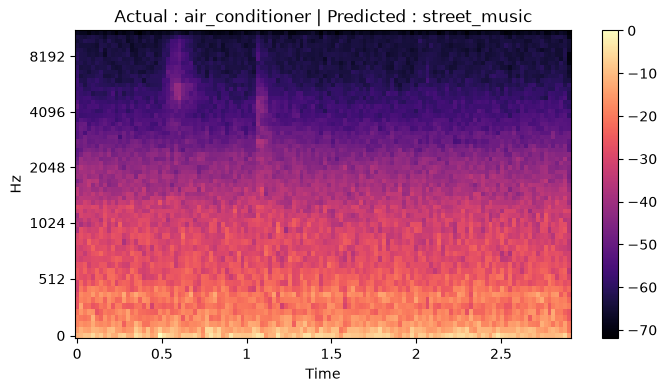

In [ ]:
for i in range(3):

    spec,label,pred = incorrect[i]

    plt.figure(figsize=(8,4))

    librosa.display.specshow(
        spec.squeeze().numpy(),
        x_axis="time",
        y_axis="mel"
    )

    plt.title(
        f"Actual : {encoder.inverse_transform([label])[0]} | "
        f"Predicted : {encoder.inverse_transform([pred])[0]}"
    )

    plt.colorbar()

    plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision_A, recall_A, f1_A, _ = precision_recall_fscore_support(
    true_labels,
    predictions,
    average="macro"
)

print("Macro Precision:", precision_A)
print("Macro Recall:", recall_A)
print("Macro F1:", f1_A)

Macro Precision: 0.8931177074048939
Macro Recall: 0.8708409096898304
Macro F1: 0.876060021528137


In [ ]:
precision_B, recall_B, f1_B, _ = precision_recall_fscore_support(
    true_labels_aug,
    predictions_aug,
    average="macro"
)

print("Macro Precision:", precision_B)
print("Macro Recall:", recall_B)
print("Macro F1:", f1_B)

Macro Precision: 0.7584996128291888
Macro Recall: 0.682994083853796
Macro F1: 0.6815533761692001


In [ ]:
comparison = {

    "Metric":[
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],

    "Without SpecAugment":[
        test_accuracy,
        precision_A,
        recall_A,
        f1_A
    ],

    "With SpecAugment":[
        test_accuracy_aug,
        precision_B,
        recall_B,
        f1_B
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Metric,Without SpecAugment,With SpecAugment
0,Test Accuracy,0.864885,0.657252
1,Macro Precision,0.893118,0.758500
2,Macro Recall,0.870841,0.682994
3,Macro F1 Score,0.876060,0.681553


# Observationns
Without SpecAugment:
-Higher test accuracy (86.49%)
-Higher macro precision, recall, and F1-score
-Better class discrimination
-Lower classification errors

With SpecAugment
-Test accuracy decreased to 65.73%
-Macro F1-score decreased
-Some classes became harder to distinguish
-Strong augmentation likely removed important acoustic information

# Conclusion

For this UrbanSound8K experiment, the baseline CNN without augmentation achieved the best performance. While SpecAugment is a powerful regularization technique, the selected masking parameters were too aggressive for this relatively small dataset and simple CNN architecture, resulting in reduced classification performance.